<a href="https://colab.research.google.com/github/Basil-Maqbool/flyrank-internship-assignment1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Basil-Maqbool/flyrank-internship-assignment1/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Basil-Maqbool/flyrank-internship-assignment1"
REPO_DIR = "flyrank-internship-assignment1"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    target_dir = f"{REPO_DIR}/work/notebooks"
    if os.path.basename(os.getcwd()) != "notebooks":
        os.chdir(target_dir)

## 1. Question

*The research question and the decision it supports.*

Can we identify which web pages will experience trailing 90-day traffic declines using historical engagement and content metrics?
Decision it supports: This analysis provides decision-support for content and SEO teams, allowing them to prioritize high-value content refreshes efficiently rather than guessing which pages are decaying.

In [2]:
print("Focus: Predicting content decay to prioritize refresh efforts.")

Focus: Predicting content decay to prioritize refresh efforts.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

We observed data from the FlyRank internship starter dataset (content_refresh_anonymized.csv), containing ~30,000 pseudonymized content items across 32 clients.
Exclusions: We excluded rows with missing critical features (like word counts) instead of blindly filling them, to prevent injecting a category signal. All client names and private queries were strictly excluded to ensure public safety

In [3]:
import pandas as pd
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df_clean = df.dropna(subset=['content_age_days', 'days_since_last_update', 'impressions_90d', 'word_count', 'client_id'])
print(f"Data ready: {len(df_clean)} rows remaining after filtering missing features.")

Data ready: 22301 rows remaining after filtering missing features.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label Definition: We defined decay (is_declining_label) from the trend_direction column. To prevent target leakage, we strictly excluded trend_pct from the feature set.  

Features: content_age_days, days_since_last_update, impressions_90d, and word_count.  

Validation Design: We utilized a Grouped Split (GroupShuffleSplit on client_id) to ensure the model was evaluated on clients it had never seen, preventing group memorization.  

Algorithm: Random Forest Classifier.

In [4]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df_clean['is_declining_label'] = df_clean['trend_direction'].str.lower().eq('down').astype(int)
features = ['content_age_days', 'days_since_last_update', 'impressions_90d', 'word_count']
X, y, groups = df_clean[features], df_clean['is_declining_label'], df_clean['client_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

/tmp/ipykernel_455/4172821217.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['is_declining_label'] = df_clean['trend_direction'].str.lower().eq('down').astype(int)


RandomForestClassifier(max_depth=5, random_state=42)

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Random Forest model achieved a measured out-of-group Precision@50 of 0.48, compared to the heuristic baseline rule which scored 0.32. While the model outperformed the baseline, it underperformed the naive base rate (0.57), indicating that while it offers directional improvement over static rules, it requires further feature engineering for strong standalone accuracy.

In [5]:
test_df = X_test.copy()
test_df['actual_label'] = y_test
test_df['model_probability'] = rf.predict_proba(X_test)[:, 1]

def apply_baseline(row):
    if row['days_since_last_update'] >= 180 and row['impressions_90d'] >= 500: return 100
    if row['days_since_last_update'] >= 90 and row['impressions_90d'] >= 100: return 50
    return 0

test_df['baseline_score'] = test_df.apply(apply_baseline, axis=1)
model_p50 = test_df.sort_values('model_probability', ascending=False).head(50)['actual_label'].mean()
baseline_p50 = test_df.sort_values(['baseline_score', 'impressions_90d'], ascending=[False, False]).head(50)['actual_label'].mean()

print(f"Base Rate: {y.mean():.2f}")
print(f"Baseline Precision@50: {baseline_p50:.2f}")
print(f"Model Precision@50: {model_p50:.2f}")

Base Rate: 0.57
Baseline Precision@50: 0.32
Model Precision@50: 0.48


## 5. Limitations

*What this work cannot claim.*

No Causality: This is cross-sectional data. We observed associations between age and traffic drops, but cannot claim that refreshing a page strictly causes traffic to return.

 Data Blindspots: A recorded avg_position = 0 means "no data," not rank zero. Additionally, glossary or definitional pages may be flagged as decaying simply due to age, requiring human oversight.  

In [6]:
zero_pos = len(df[df['avg_position'] == 0])
print(f"Limitation verified: {zero_pos} rows have '0' position meaning 'No Data'.")

Limitation verified: 1205 rows have '0' position meaning 'No Data'.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model ranks content into a review queue using the following reason codes:  Code A (High Priority): Probability > 0.70 & Impressions > 1000. Review for immediate rewrite.

Code B (Monitor): Probability > 0.50. Monitor trailing metrics.

Code C (Low Priority): Probability < 0.50. Maintain as is.

In [7]:
def assign_code(row):
    if row['model_probability'] > 0.70 and row['impressions_90d'] > 1000: return 'Code A'
    elif row['model_probability'] >= 0.50: return 'Code B'
    else: return 'Code C'
test_df['action_code'] = test_df.apply(assign_code, axis=1)
display(test_df[['impressions_90d', 'model_probability', 'action_code']].head(3))

,impressions_90d,model_probability,action_code
0,3803,0.674328,Code B
1,15320,0.473517,Code C
5,3970,0.690080,Code B


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The following chart illustrates the model's feature importance, demonstrating its heavy reliance on trailing 90-day impressions.

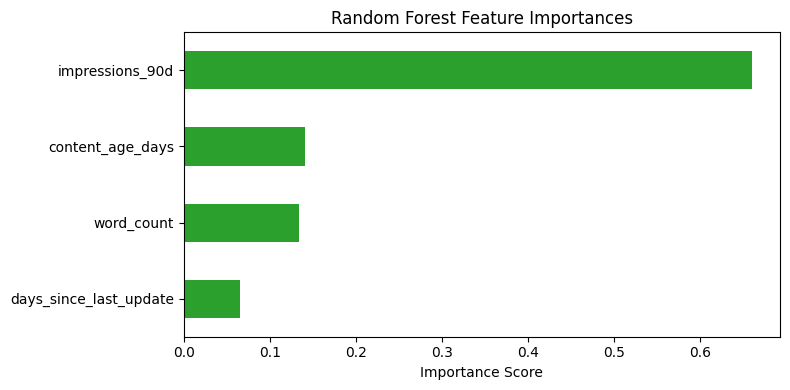

Artifact saved successfully.


In [8]:
import matplotlib.pyplot as plt
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='#2ca02c')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Artifact saved successfully.")

8. **Reproducibilty**
All code, feature engineering logic, and validation splits are fully documented and reproducible. The complete repository and Jupyter notebooks can be found at: https://github.com/Basil-Maqbool/flyrank-internship-assignment1

9. Acknowledgments & data credit
Built on the FlyRank ML Internship dataset. Find out more at https://flyrank.ai.

In [9]:
!jupyter nbconvert --to html capstone.ipynb

[NbConvertApp] Converting notebook capstone.ipynb to html
/usr/local/lib/python3.12/dist-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)
[NbConvertApp] Writing 286917 bytes to capstone.html
